In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [1]:
from sklearn.linear_model import LinearRegression

In [3]:
np.random.seed(42)
X = np.random.rand(50,1)*100
Y = 3.5 * X + np.random.randn(50,1)*20

In [4]:
model = LinearRegression()
model.fit(X,Y)

LinearRegression()

In [5]:
Y_pred = model.predict(X)

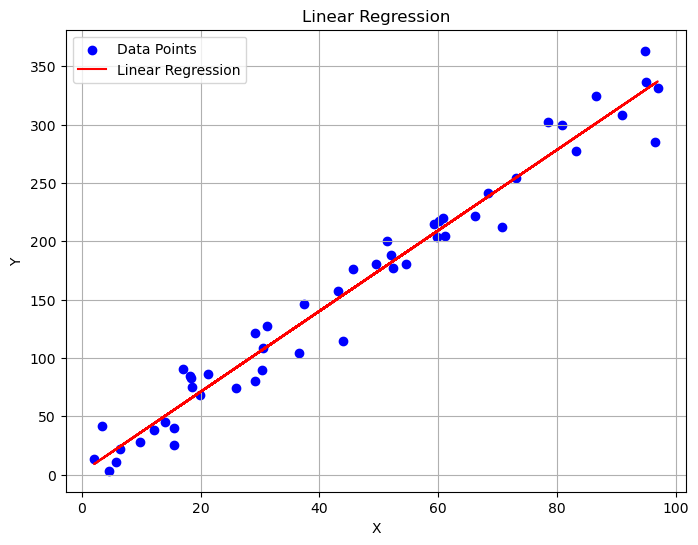

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(X,Y,color='blue', label='Data Points')
plt.plot(X, Y_pred, color='red', label='Linear Regression')
plt.title('Linear Regression')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid()
plt.show()

In [12]:
print('m:',model.coef_[0][0])
print('c:', model.intercept_[0])
print('R-squared:', model.score(X,Y))

m: 3.4553132007706204
c: 1.9337854893777546
R-squared: 0.9673825411815328


In [13]:
#multiple LR
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [16]:
df = pd.read_csv("C:/Users/hp/Downloads/House prediction/data.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,NaN,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [17]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.282834,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.703543,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.619000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


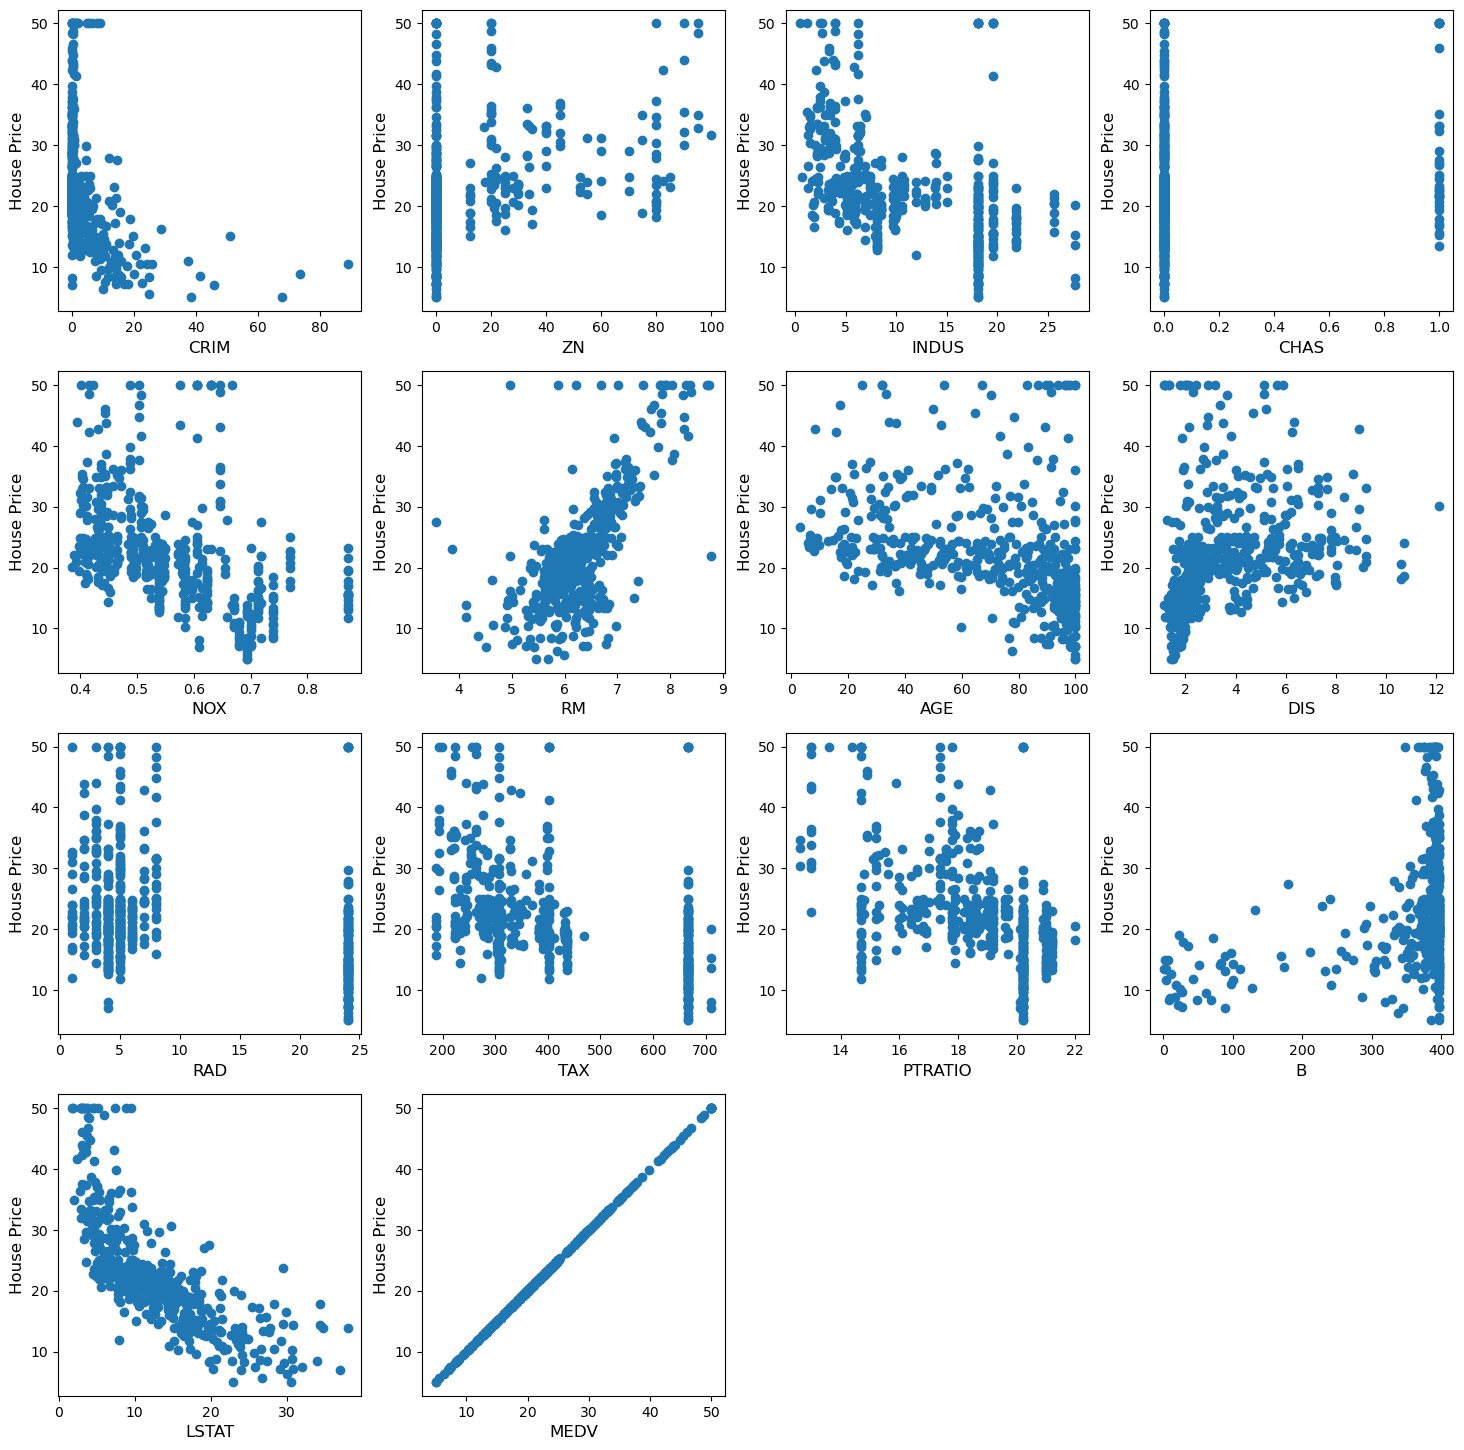

In [26]:
fig = plt.figure(figsize=(18,18))
for index, feature_name in enumerate(df.columns):
    ax = fig.add_subplot(4,4,index+1)
    ax.scatter(df.values[:,index],
              df['MEDV'])
    ax.set_ylabel('House Price', size=12)
    ax.set_xlabel(feature_name, size=12)
plt.show()

In [28]:
#some variables not very much correlated with target, these variables will get their coeff reduced in regularization.

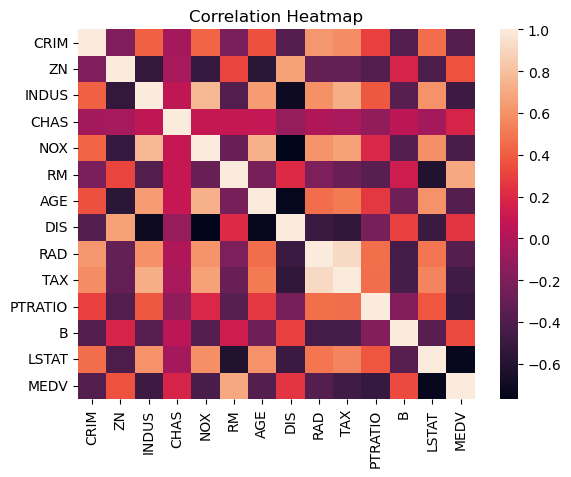

In [43]:
import seaborn as sns
cor = df.corr()
sns.heatmap(cor)
plt.title('Correlation Heatmap')
plt.show()

In [56]:
df['RM'] = df['RM'].fillna(df['RM'].mean())

In [57]:
#divide into independent and dependent features
X = df.iloc[:,:-1]
Y = df.iloc[:,-1]

In [58]:
x_train, x_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df.iloc[:,-1], test_size=0.25)
print(f"Training set shape x:{x_train.shape} and y={y_train.shape}")
print(f"Testing set shape x:{x_test.shape} and y:{y_test.shape}")

Training set shape x:(379, 13) and y=(379,)
Testing set shape x:(127, 13) and y:(127,)


### Multiple Linear Regression

In [59]:
lreg = LinearRegression()
lreg.fit(x_train, y_train)

lreg_pred = lreg.predict(x_test)

In [60]:
# mse
mean_squared_error = np.mean((lreg_pred - y_test)**2)
print('MSE on test-set: ',mean_squared_error)

MSE on test-set:  32.9780892279761


In [66]:
# coefficients
lreg_coeff = pd.DataFrame()
lreg_coeff['Columns'] = x_train.columns
lreg_coeff['Coefficient'] = pd.Series(lreg.coef_)
print(lreg_coeff)

    Columns  Coefficient
0      CRIM    -0.150671
1        ZN     0.051029
2     INDUS     0.005537
3      CHAS     1.041351
4       NOX   -16.633954
5        RM     4.450134
6       AGE    -0.008448
7       DIS    -1.516272
8       RAD     0.342126
9       TAX    -0.015214
10  PTRATIO    -1.008559
11        B     0.011136
12    LSTAT    -0.427356


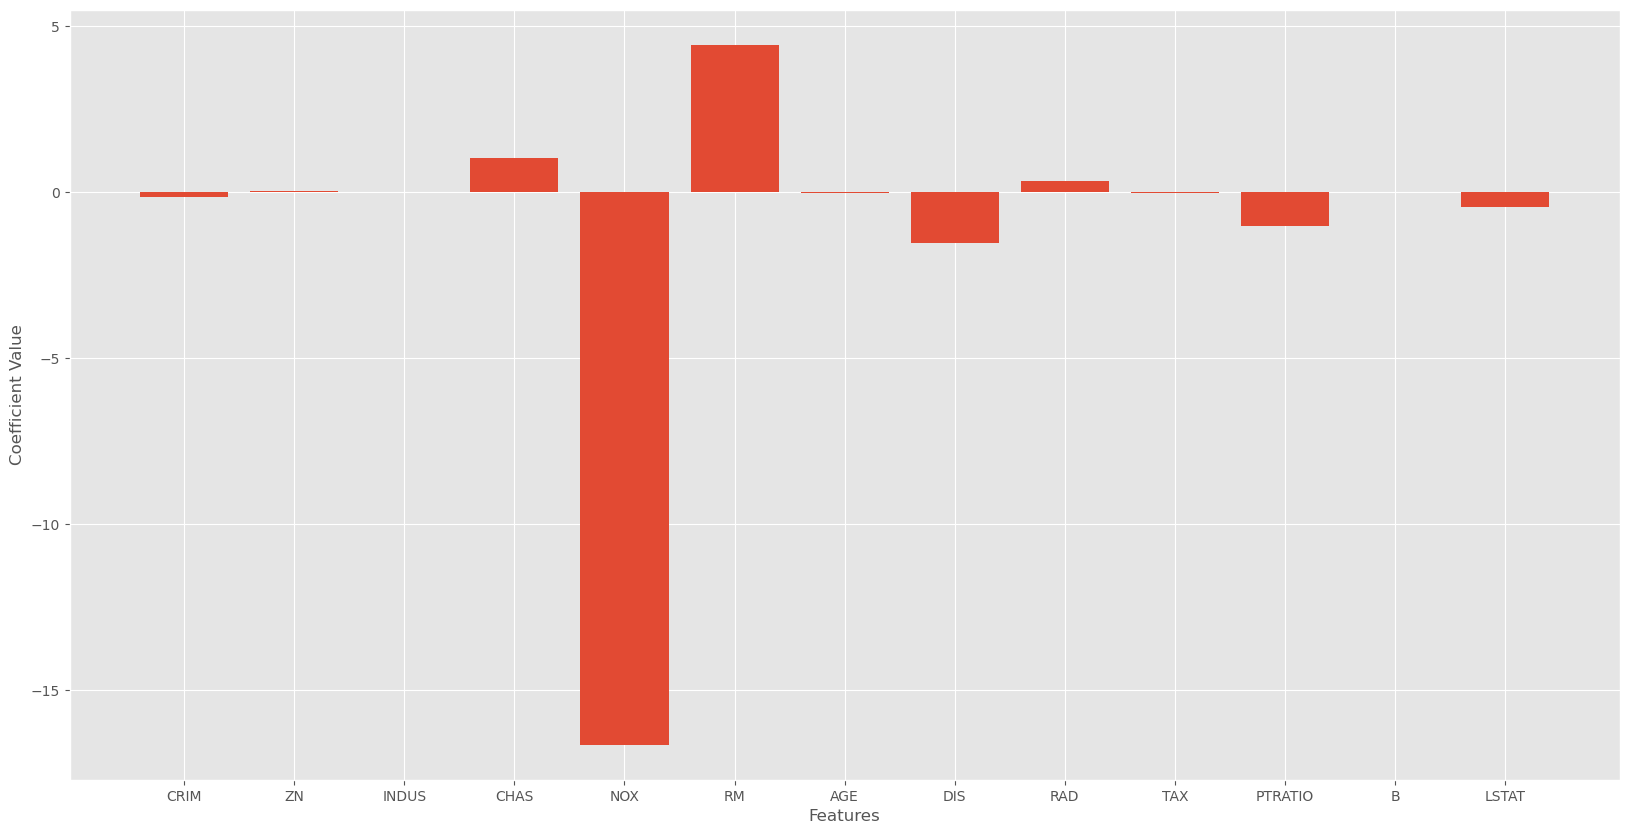

In [78]:
#when plotting like fig, ax -> all commands wrt ax and not plt because is explicit
fig,ax = plt.subplots(figsize=(20,10))
ax.bar(lreg_coeff['Columns'], lreg_coeff['Coefficient'])
ax.set_xlabel('Features')
ax.set_ylabel('Coefficient Value')
ax.grid(True)
plt.show()

In [79]:
#lots of insignificant variables, need to regulate or even eliminate

### Ridge Regression

In [80]:
from sklearn.linear_model import Ridge

In [82]:
ridgeR = Ridge(alpha=1) #alpha=lambda
ridgeR.fit(x_train, y_train)
y_pred = ridgeR.predict(x_test)

mean_sq_error_ridge = np.mean((y_pred - y_test)**2)
print('MSE Ridge:', mean_sq_error_ridge)

MSE Ridge: 33.50712269595214


In [85]:
ridge_coef = pd.DataFrame()
ridge_coef['Columns'] = x_train.columns
ridge_coef['Coefficient'] = pd.Series(ridgeR.coef_)
print(ridge_coef.sort_values(by='Coefficient',ascending=False))

    Columns  Coefficient
5        RM     4.510006
3      CHAS     0.925560
8       RAD     0.319719
1        ZN     0.051873
11        B     0.011509
9       TAX    -0.015674
6       AGE    -0.015800
2     INDUS    -0.028095
0      CRIM    -0.148231
12    LSTAT    -0.431070
10  PTRATIO    -0.925626
7       DIS    -1.414026
4       NOX    -9.156752


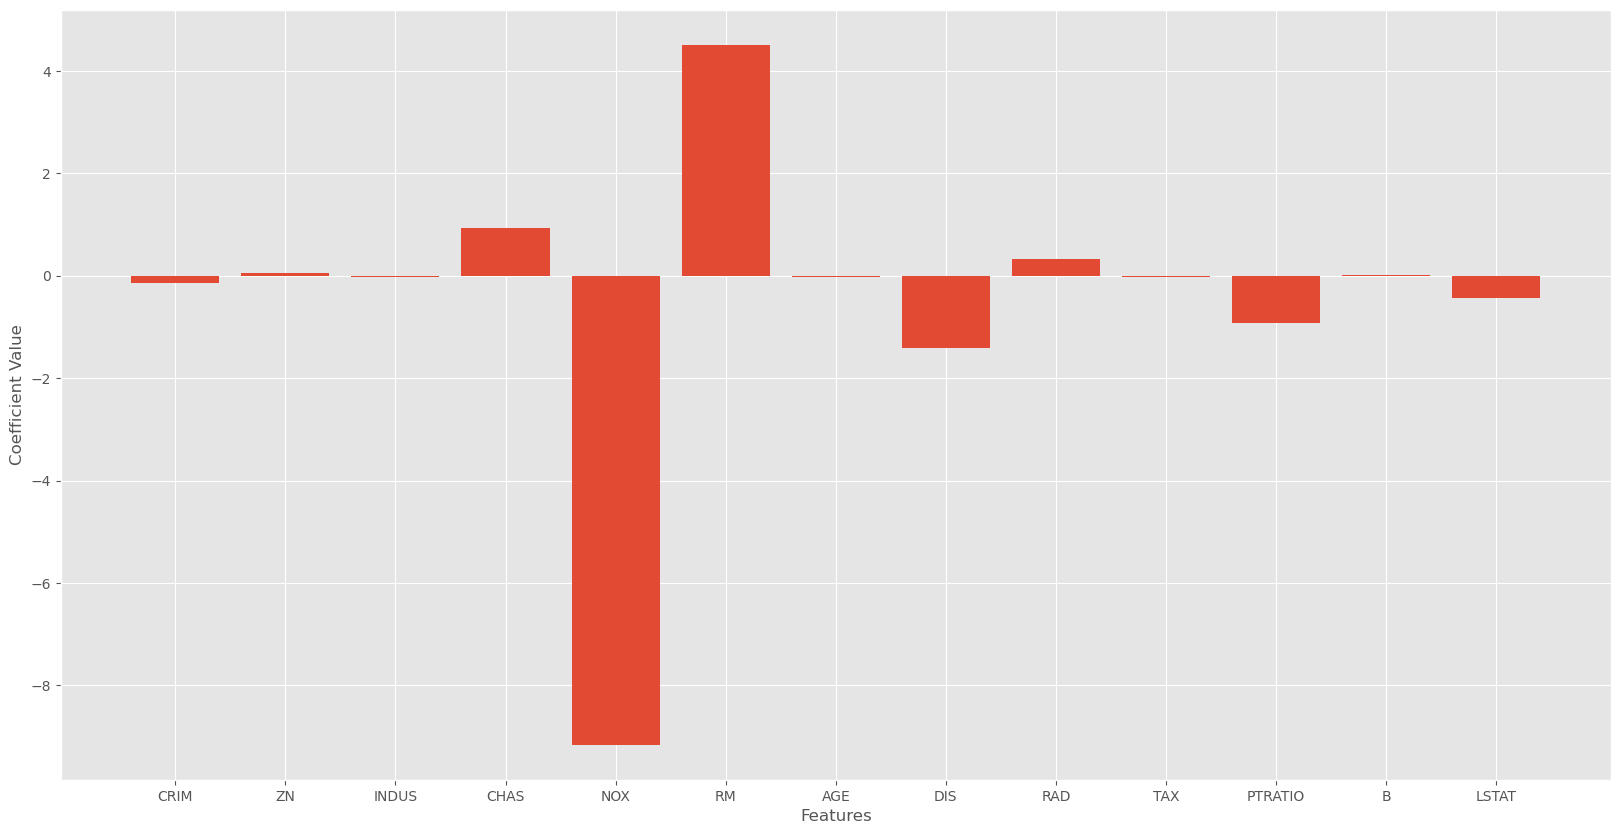

In [88]:
fig, ax = plt.subplots(figsize=(20,10))
ax.bar(ridge_coef['Columns'],ridge_coef['Coefficient'])
ax.set_xlabel('Features')
ax.set_ylabel('Coefficient Value')
ax.grid(True)
plt.show()

In [89]:
ridge10 = Ridge(alpha=10)
ridge10.fit(x_train, y_train)
y_pred = ridge10.predict(x_test)

mean_ridge10 = np.mean((y_pred - y_test)**2)
print('MSE for alpha=10:',mean_ridge10)

MSE for alpha=10: 33.92329618441557


In [92]:
r10 = pd.DataFrame()
r10['Columns'] = x_train.columns
r10['Coefficient'] = pd.Series(ridge10.coef_)
print(r10.sort_values(by='Coefficient', ascending=False))

    Columns  Coefficient
5        RM     4.245979
3      CHAS     0.661519
8       RAD     0.307750
1        ZN     0.053905
11        B     0.011606
9       TAX    -0.016507
6       AGE    -0.020256
2     INDUS    -0.064180
0      CRIM    -0.144859
12    LSTAT    -0.458630
10  PTRATIO    -0.859318
7       DIS    -1.313159
4       NOX    -1.831264


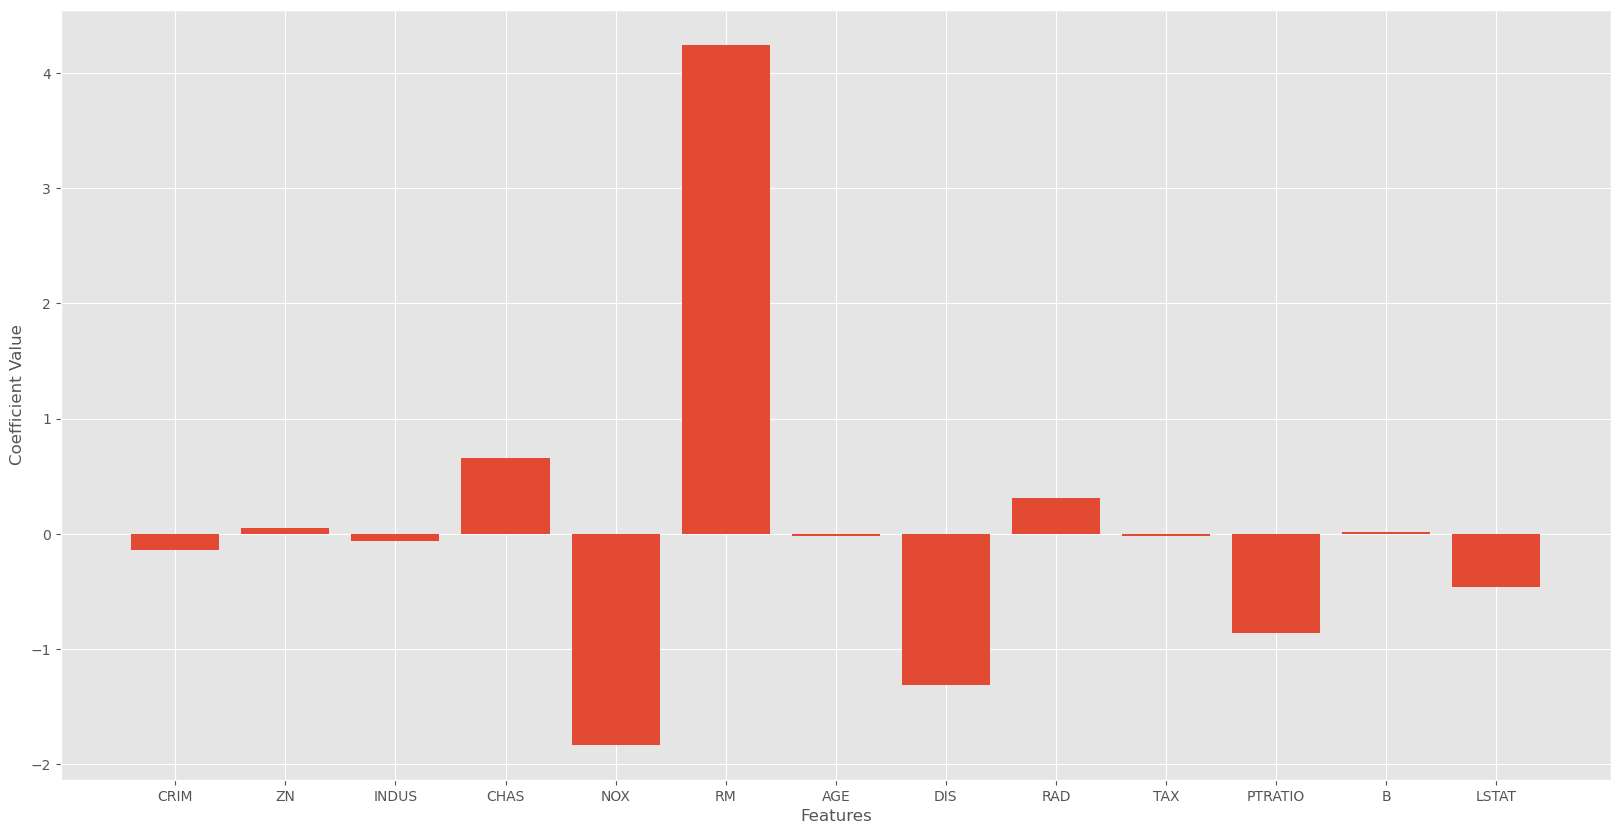

In [94]:
fig, ax = plt.subplots(figsize=(20,10))
ax.bar(r10['Columns'], r10['Coefficient'])
ax.set_xlabel('Features')
ax.set_ylabel('Coefficient Value')
plt.show()

### Lasso Regression

In [95]:
from sklearn.linear_model import Lasso

In [96]:
lasso = Lasso(alpha=1)
lasso.fit(x_train, y_train)
y_pred = lasso.predict(x_test)

mse_lasso = np.mean((y_pred-y_test)**2)
print('MSE for Lasso:',mse_lasso)

MSE for Lasso: 32.27249625083123


In [98]:
lasso_coef = pd.DataFrame()
lasso_coef['Columns'] = x_train.columns
lasso_coef['Coefficient'] = pd.Series(lasso.coef_)
print(lasso_coef)

    Columns  Coefficient
0      CRIM    -0.082794
1        ZN     0.048068
2     INDUS    -0.008837
3      CHAS     0.000000
4       NOX    -0.000000
5        RM     1.769509
6       AGE     0.011963
7       DIS    -0.624824
8       RAD     0.270917
9       TAX    -0.016927
10  PTRATIO    -0.765590
11        B     0.008823
12    LSTAT    -0.650686


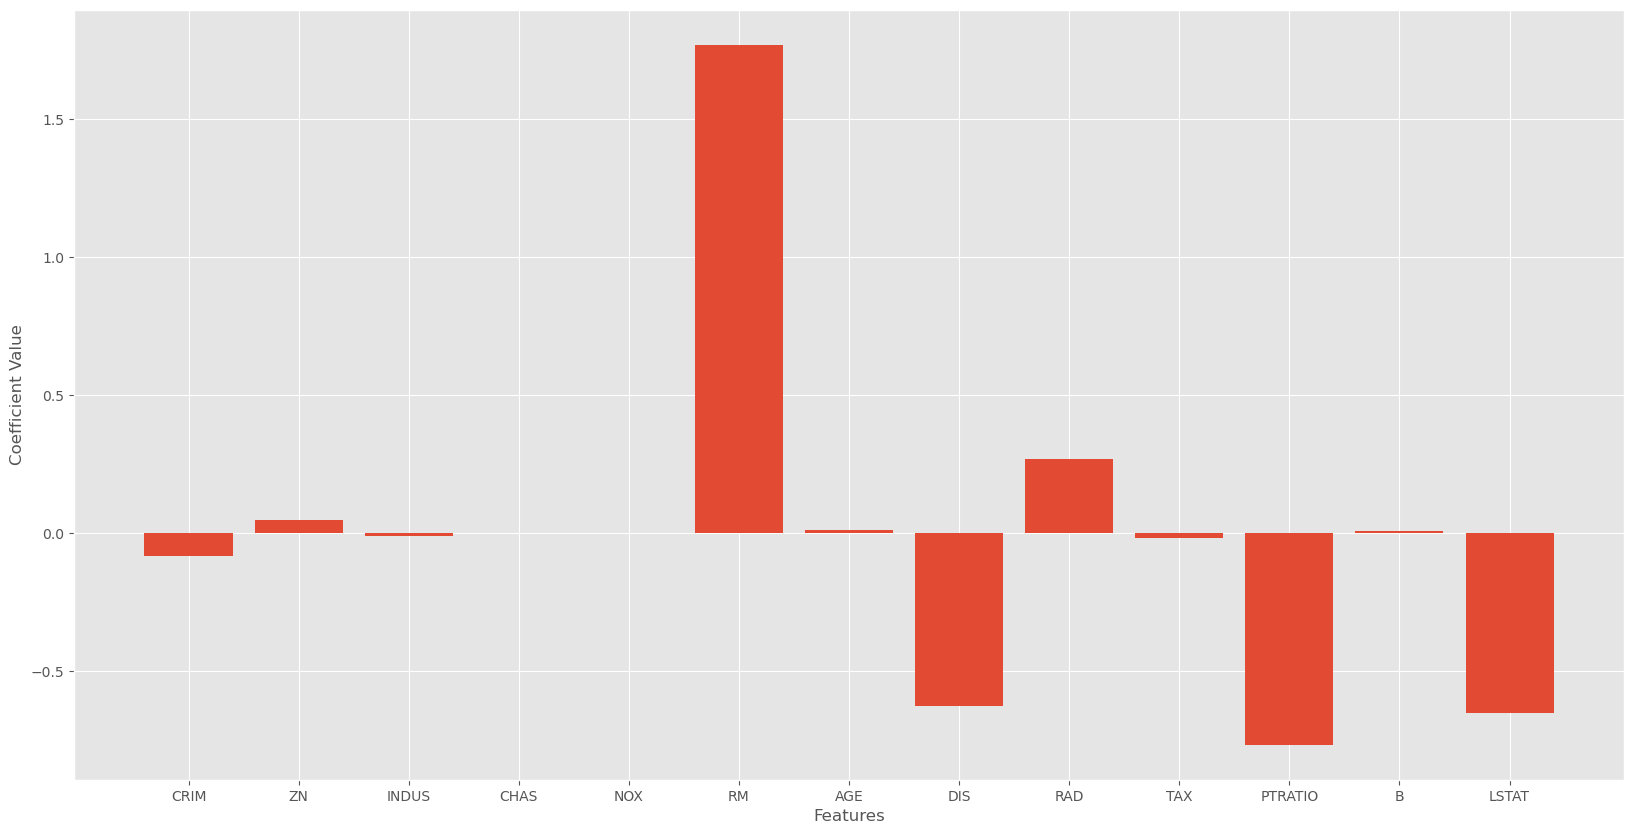

In [99]:
fig, ax = plt.subplots(figsize=(20,10))
ax.bar(lasso_coef['Columns'], lasso_coef['Coefficient'])
ax.set_xlabel('Features')
ax.set_ylabel('Coefficient Value')
plt.show()

### Elastic Net Regression

In [100]:
from sklearn.linear_model import ElasticNet

In [101]:
enet = ElasticNet(alpha=1)
enet.fit(x_train, y_train)
y_pred = enet.predict(x_test)

mse_enet = np.mean((y_pred - y_test)**2)
print('MSE Elastic Net:',mse_enet)

MSE Elastic Net: 32.16489696405624


In [103]:
enet_coef = pd.DataFrame()
enet_coef['Columns'] = x_train.columns
enet_coef['Coefficient'] = pd.Series(enet.coef_)
print(enet_coef)

    Columns  Coefficient
0      CRIM    -0.101510
1        ZN     0.054942
2     INDUS    -0.051735
3      CHAS     0.000000
4       NOX    -0.000000
5        RM     1.203711
6       AGE     0.015213
7       DIS    -0.783863
8       RAD     0.321827
9       TAX    -0.018245
10  PTRATIO    -0.807078
11        B     0.008540
12    LSTAT    -0.686510


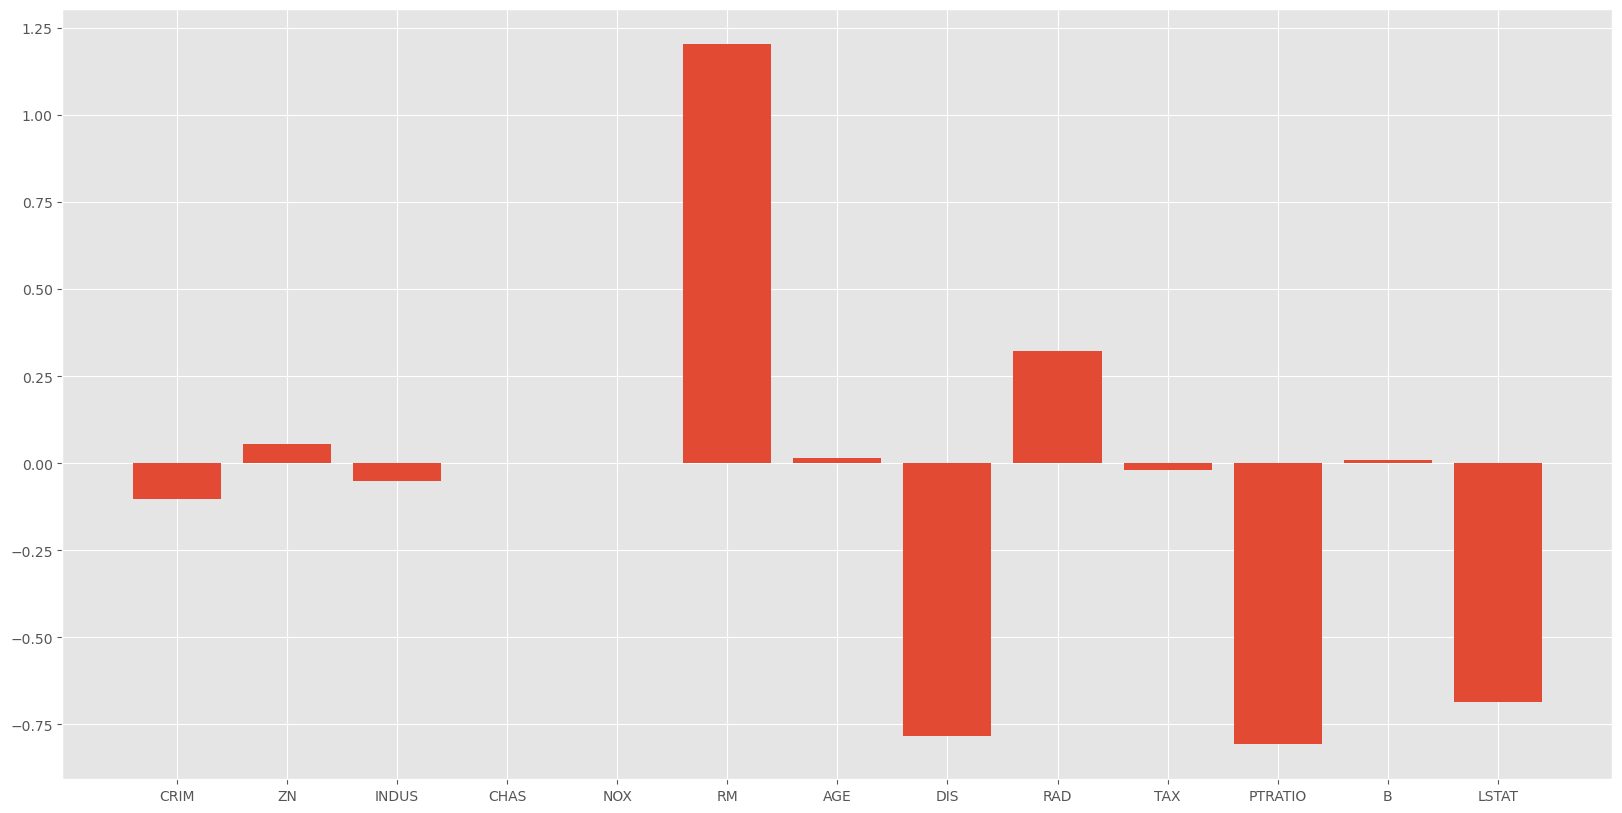

In [105]:
fig, ax = plt.subplots(figsize=(20,10))
ax.bar(enet_coef['Columns'], enet_coef['Coefficient'])
plt.show()